# Семинар 2 · Линейная регрессия: решение и оптимизация

**Формат:** управляемая демонстрация на 90 минут. Перед ключевыми запусками сначала сформулируйте прогноз, затем сравните его с результатом.

Сегодня одна модель проходит три пути: аналитическое решение, полный градиент и случайные мини-батчи. На почти совпадающих признаках увидим, почему точный прогноз не гарантирует устойчивых коэффициентов.

**Маршрут:** синтетические данные → метод наименьших квадратов → зависимые признаки и регуляризация → GD/SGD → масштабирование и `sklearn`.

## Ритм занятия

| Время | Блок | Что предсказать до запуска |
|---:|---|---|
| 0–20 мин | Данные и прямая/плоскость | Какие роли у коэффициентов и свободного члена? |
| 20–40 мин | МНК и зависимые признаки | Что произойдёт с коэффициентами при почти одинаковых столбцах? |
| 40–55 мин | Регуляризация | Что уменьшится: ошибка на train или величина весов? |
| 55–75 мин | GD и мини-батчи | Как выглядят траектории потерь? |
| 75–90 мин | Масштаб и `sklearn` | Почему масштабирование обучают только на train? |

Нужны `numpy`, `matplotlib` и `scikit-learn`. Все данные создаются в ноутбуке; фиксированный seed делает запуски воспроизводимыми.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=3, suppress=True)
print(f"NumPy {np.__version__}; scikit-learn {sklearn.__version__}; seed {SEED}")

NumPy 2.5.3; scikit-learn 1.9.1; seed 42


## 1. Маленький мир с известным ответом

Как и в лекциях, $m$ — число наблюдений, $n$ — число признаков. Матрица $\mathbf X\in\mathbb R^{m\times n}$ содержит объекты по строкам. Вектор $\mathbf x^{(i)}$ описывает объект $i$, его координата $x_j^{(i)}$ — признак $j$, а $y^{(i)}$ — скалярный ответ. Все ответы вместе образуют вектор $\mathbf y$.

Создадим два признака и ответы $\mathbf y=\mathbf X\mathbf w_*+b_*\mathbf1+\boldsymbol\varepsilon$, где $\mathbf w_*=(1.7,-0.8)^\mathsf T$, $b_*=1.5$, а шум имеет нулевое среднее. Здесь $\mathbf X$ содержит **только признаки**; столбец единиц для свободного члена добавим последним, как в слайдах. Отложим test до оценки обученной модели. В коде `n_samples` — число наблюдений, то есть $m$, а не число признаков.

**До запуска:** как изменится плоскость, если увеличить только $b$? Что изменится при увеличении $w_1$?

train: (135, 2); test: (45, 2)
true weights: [ 1.7 -0.8]; true bias: 1.5


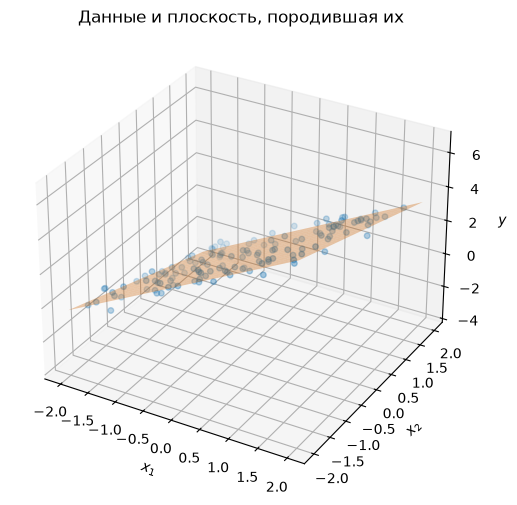

In [2]:
n_samples = 180
w_true = np.array([1.7, -0.8])
b_true = 1.5
X = rng.uniform(-2, 2, size=(n_samples, 2))
y = X @ w_true + b_true + rng.normal(0, 0.35, n_samples)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED
)
print(f"train: {X_train.shape}; test: {X_test.shape}")
print(f"true weights: {w_true}; true bias: {b_true}")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(X_train[:, 0], X_train[:, 1], y_train, s=16, alpha=0.65, label="train")
grid_1, grid_2 = np.meshgrid(np.linspace(-2, 2, 18), np.linspace(-2, 2, 18))
plane = w_true[0] * grid_1 + w_true[1] * grid_2 + b_true
ax.plot_surface(grid_1, grid_2, plane, color="tab:orange", alpha=0.35)
ax.set(xlabel="$x_1$", ylabel="$x_2$", zlabel="$y$", title="Данные и плоскость, породившая их")
plt.show()

<details><summary><b>Разбор</b></summary>

Свободный член сдвигает плоскость вдоль оси ответа, не меняя наклонов. Коэффициент при первом признаке меняет наклон в направлении этой оси. Шум объясняет, почему точки не лежат ровно на плоскости.

</details>

## 2. МНК: от ошибки к коэффициентам

Допишем столбец единиц **справа**: $\tilde{\mathbf X}=[\mathbf X\ \mathbf1]$. Вектор всех параметров $\boldsymbol\theta=\tilde{\mathbf w}=(w_1,w_2,b)^\mathsf T$ имеет тот же порядок, что в лекции. В коде расширенная матрица называется `A_train`, а вектор параметров — `theta_ols`.

Потеря одного объекта — $\ell(y^{(i)},\hat y^{(i)})=(y^{(i)}-\hat y^{(i)})^2$. Для $m$ обучающих наблюдений минимизируем **среднюю** квадратичную ошибку:

$$Q(\boldsymbol\theta)=\frac1m\sum_{i=1}^m\ell(y^{(i)},\hat y^{(i)})=\frac1m\lVert\tilde{\mathbf X}\boldsymbol\theta-\mathbf y\rVert_2^2,$$
$$\nabla Q(\boldsymbol\theta)=\frac2m\tilde{\mathbf X}^\mathsf T(\tilde{\mathbf X}\boldsymbol\theta-\mathbf y).$$

Нормальное уравнение: $\tilde{\mathbf X}^\mathsf T\tilde{\mathbf X}\hat{\boldsymbol\theta}=\tilde{\mathbf X}^\mathsf T\mathbf y$. Формула $\hat{\boldsymbol\theta}=(\tilde{\mathbf X}^\mathsf T\tilde{\mathbf X})^{-1}\tilde{\mathbf X}^\mathsf T\mathbf y$ применима **только при обратимости матрицы**. На практике `lstsq` находит решение без явного обращения. Параметры оцениваем только на train; test используем для оценки, а не для выбора настроек.

**До запуска:** совпадут ли найденные параметры в точности с $\mathbf w_*,b_*$? Почему?

In [3]:
A_train = np.column_stack([X_train, np.ones(len(X_train))])
A_test = np.column_stack([X_test, np.ones(len(X_test))])
theta_ols, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)
train_pred = A_train @ theta_ols
test_pred = A_test @ theta_ols
print(f"true (w1, w2, b): {np.r_[w_true, b_true]}")
print(f"OLS  (w1, w2, b): {theta_ols}")
print(f"train MSE: {mean_squared_error(y_train, train_pred):.4f}")
print(f"test  MSE: {mean_squared_error(y_test, test_pred):.4f}")
assert np.linalg.norm(A_train.T @ (A_train @ theta_ols - y_train)) < 1e-9

true (w1, w2, b): [ 1.7 -0.8  1.5]
OLS  (w1, w2, b): [ 1.704 -0.784  1.499]
train MSE: 0.1301
test  MSE: 0.1124


<details><summary><b>Разбор</b></summary>

Шум и конечный размер выборки меняют оценку коэффициентов. Небольшое расхождение с истинными весами не означает ошибку метода. Проверка нормального уравнения выше относится к train; test не участвовал в вычислении параметров.

</details>

## 3. Почти одинаковые признаки

Если $x_2=x_1$, то отдельные $w_1$ и $w_2$ нельзя восстановить: прогноз зависит от их суммы. При $x_2\approx x_1$ задача становится чувствительной к шуму. Чтобы увидеть это, обучим две модели на **тех же признаках**, но с двумя независимыми реализациями шума в цели.

**До запуска:** если оба набора прогнозов похожи, обязательно ли будут похожи коэффициенты? Сначала проверим точное совпадение признаков, затем почти совпадение.

In [4]:
exact_x = np.linspace(-1, 1, 6)
A_exact = np.column_stack([exact_x, exact_x, np.ones(len(exact_x))])
y_exact = 1 + 3 * exact_x
exact_theta, *_ = np.linalg.lstsq(A_exact, y_exact, rcond=None)
print(f"exact duplicate: rank={np.linalg.matrix_rank(A_exact)} of 3; lstsq weights={exact_theta[:-1]}")
print(f"alternative (1, 2) produces the same predictions: {np.allclose(A_exact @ [1, 2, 1], y_exact)}")

cor_rng = np.random.default_rng(SEED + 1)
X_cor = np.column_stack([
    cor_rng.normal(size=160),
    np.zeros(160),
])
X_cor[:, 1] = X_cor[:, 0] + cor_rng.normal(0, 0.001, len(X_cor))
cor_signal = X_cor @ np.array([2.0, 1.0]) + 1.0
Y_cor = [cor_signal + cor_rng.normal(0, 0.2, len(X_cor)) for _ in range(2)]
A_cor = np.column_stack([X_cor, np.ones(len(X_cor))])
ols_cor = [np.linalg.lstsq(A_cor, target, rcond=None)[0] for target in Y_cor]
print(f"condition number of A: {np.linalg.cond(A_cor):.0f}")
for i, theta in enumerate(ols_cor, 1):
    print(f"noise {i}: weights={theta[:-1]}, sum={theta[:-1].sum():.3f}, train MSE={mean_squared_error(Y_cor[i-1], A_cor @ theta):.4f}")
print(f"RMS difference between fitted predictions: {np.sqrt(np.mean((A_cor @ ols_cor[0] - A_cor @ ols_cor[1])**2)):.4f}")

exact duplicate: rank=2 of 3; lstsq weights=[1.5 1.5]
alternative (1, 2) produces the same predictions: True
condition number of A: 2214
noise 1: weights=[-21.106  24.102], sum=2.996, train MSE=0.0379
noise 2: weights=[ 17.069 -14.085], sum=2.984, train MSE=0.0340
RMS difference between fitted predictions: 0.0486


<details><summary><b>Разбор</b></summary>

Когда столбцы почти повторяются, изменение одного веса можно компенсировать изменением другого. Поэтому близость **предсказаний на наблюдаемой области** не доказывает устойчивость каждого коэффициента. Большое число обусловленности здесь указывает на чувствительность задачи к возмущениям.

</details>

### Регуляризация: ограничиваем размер весов

Штрафуем только коэффициенты признаков, **не** свободный член:

$$Q_{\mathrm{reg}}(\mathbf w,b)=\frac1m\lVert\mathbf X\mathbf w+b\mathbf1-\mathbf y\rVert_2^2+\lambda\lVert\mathbf w\rVert_2^2,\qquad\lambda>0.$$

Для $\tilde{\mathbf X}=[\mathbf X\ \mathbf1]$ получаем

$$(\tilde{\mathbf X}^\mathsf T\tilde{\mathbf X}+m\lambda\mathbf D)\hat{\boldsymbol\theta}=\tilde{\mathbf X}^\mathsf T\mathbf y,$$

где $\mathbf D=\operatorname{diag}(1,1,0)$: последний параметр — свободный член. В `sklearn.Ridge` параметр `alpha` соответствует **$m\lambda$**, потому что её критерий содержит сумму квадратов ошибок, а не MSE. Здесь $m$ — число наблюдений конкретного обучающего эксперимента.

**До запуска:** сравните разброс отдельных весов и ошибку на обучении. Может ли штраф ухудшить train MSE?

noise 1: ridge weights=[1.463 1.463], sum=2.926, train MSE=0.0433
noise 2: ridge weights=[1.459 1.459], sum=2.918, train MSE=0.0391


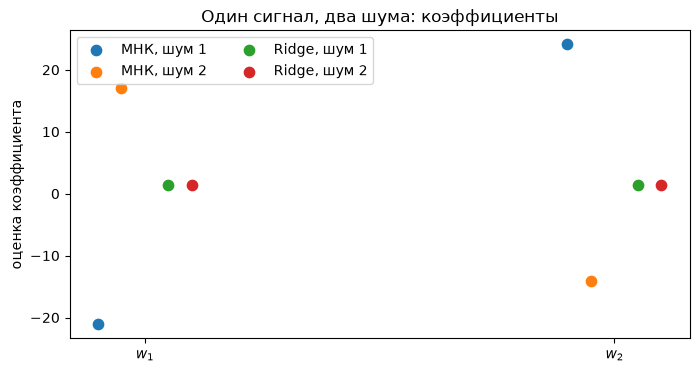

In [5]:
lam = 0.05
penalty = np.diag([1.0, 1.0, 0.0])
ridge_cor = [
    np.linalg.solve(A_cor.T @ A_cor + len(X_cor) * lam * penalty, A_cor.T @ target)
    for target in Y_cor
]
for i, theta in enumerate(ridge_cor, 1):
    print(f"noise {i}: ridge weights={theta[:-1]}, sum={theta[:-1].sum():.3f}, train MSE={mean_squared_error(Y_cor[i-1], A_cor @ theta):.4f}")
check_ridge = Ridge(alpha=len(X_cor) * lam).fit(X_cor, Y_cor[0])
assert np.allclose(np.r_[check_ridge.coef_, check_ridge.intercept_], ridge_cor[0], atol=1e-8)
assert np.linalg.norm(ridge_cor[0][:-1] - ridge_cor[1][:-1]) < np.linalg.norm(ols_cor[0][:-1] - ols_cor[1][:-1])

fig, ax = plt.subplots(figsize=(8, 4))
positions = np.arange(2)
for j, (name, params) in enumerate([("МНК", ols_cor), ("Ridge", ridge_cor)]):
    for i, theta in enumerate(params):
        ax.scatter(positions + (j - 0.5) * 0.15 + (i - 0.5) * 0.05, theta[:-1], label=f"{name}, шум {i+1}", s=55)
ax.set_xticks(positions, ["$w_1$", "$w_2$"])
ax.set_ylabel("оценка коэффициента")
ax.set_title("Один сигнал, два шума: коэффициенты")
ax.legend(ncol=2)
plt.show()

<details><summary><b>Разбор</b></summary>

Штраф удерживает веса ближе к нулю и уменьшает их изменение между двумя реализациями шума. Он может повысить train MSE, потому что оптимизирует **MSE плюс штраф**. Здесь проверена устойчивость коэффициентов в конкретном эксперименте; это не обещание улучшения test при любом $\lambda$.

</details>

## 4. Полный градиентный спуск

Вернёмся к первым данным и функции $Q(\boldsymbol\theta)=\mathrm{MSE}$. Из нулевого вектора повторяем $\boldsymbol\theta_{t+1}=\boldsymbol\theta_t-\eta\nabla Q(\boldsymbol\theta_t)$. Полный градиент использует **все train-объекты**. Сравним траекторию с МНК; test при настройке шага не нужен.

**До запуска:** что будет с потерей при слишком большом шаге $\eta$? Почему маленький шаг может быть неудобен?

OLS: [ 1.704 -0.784  1.499]; GD: [ 1.704 -0.784  1.499]
train MSE: 0.1301 (GD), 0.1301 (МНК)


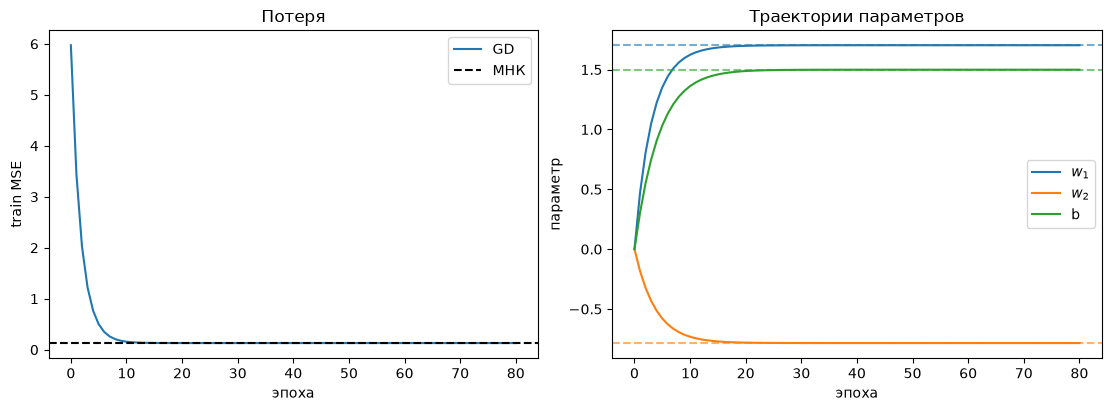

In [6]:
def mse_gradient(A, target, theta):
    return 2 * A.T @ (A @ theta - target) / len(target)

learning_rate = 0.12
n_epochs = 80
theta_gd = np.zeros(A_train.shape[1])
gd_history = [theta_gd.copy()]
gd_loss = [mean_squared_error(y_train, A_train @ theta_gd)]
for _ in range(n_epochs):
    theta_gd -= learning_rate * mse_gradient(A_train, y_train, theta_gd)
    gd_history.append(theta_gd.copy())
    gd_loss.append(mean_squared_error(y_train, A_train @ theta_gd))
gd_history = np.array(gd_history)
print(f"OLS: {theta_ols}; GD: {theta_gd}")
print(f"train MSE: {gd_loss[-1]:.4f} (GD), {mean_squared_error(y_train, train_pred):.4f} (МНК)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(gd_loss, label="GD")
axes[0].axhline(mean_squared_error(y_train, train_pred), color="black", ls="--", label="МНК")
axes[0].set(xlabel="эпоха", ylabel="train MSE", title="Потеря")
axes[0].legend()
for j, name in enumerate(["$w_1$", "$w_2$", "b"]):
    axes[1].plot(gd_history[:, j], label=name)
    axes[1].axhline(theta_ols[j], color=f"C{j}", ls="--", alpha=0.6)
axes[1].set(xlabel="эпоха", ylabel="параметр", title="Траектории параметров")
axes[1].legend()
plt.show()

<details><summary><b>Разбор</b></summary>

Для выбранного шага полный GD сходится к решению МНК: минимум у них общий. Это не правило для любого шага. Длина шага зависит от масштаба признаков и кривизны функции потерь.

</details>

## 5. Случайные мини-батчи

Теперь каждый шаг использует до 16 train-объектов в случайном порядке; последний мини-батч может быть короче. После каждой эпохи измеряем **полную train MSE**, чтобы сравнение с GD было содержательным. Шаги мини-батчей шумят; при постоянной скорости обучения траектория может колебаться вокруг минимума.

**До запуска:** обязана ли потеря после каждой эпохи строго уменьшаться?

МНК train MSE: 0.1301
GD  train MSE: 0.1301; SGD train MSE: 0.1304
steps per epoch: GD = 1 full batch, SGD = 9 mini-batches


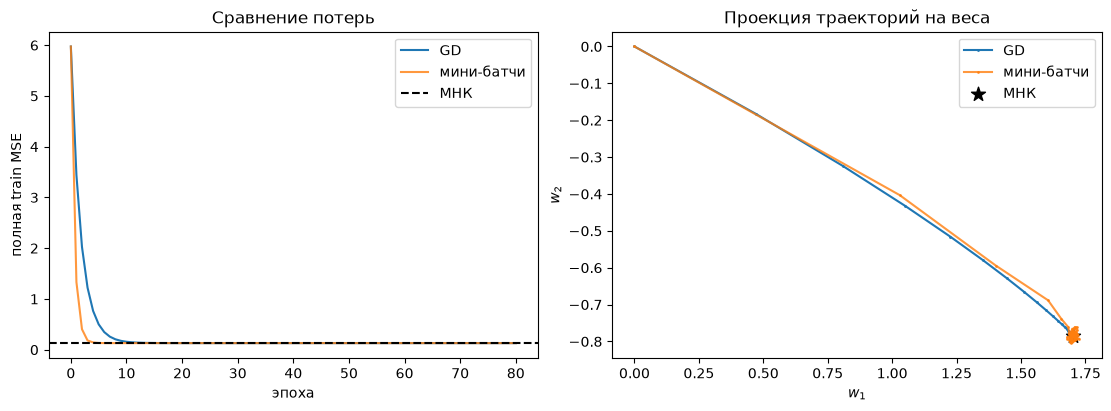

In [7]:
sgd_rng = np.random.default_rng(SEED + 2)
batch_size = 16
sgd_rate = 0.04
theta_sgd = np.zeros(A_train.shape[1])
sgd_history = [theta_sgd.copy()]
sgd_loss = [mean_squared_error(y_train, A_train @ theta_sgd)]
for _ in range(n_epochs):
    order = sgd_rng.permutation(len(y_train))
    for start in range(0, len(y_train), batch_size):
        batch = order[start:start + batch_size]
        theta_sgd -= sgd_rate * mse_gradient(A_train[batch], y_train[batch], theta_sgd)
    sgd_history.append(theta_sgd.copy())
    sgd_loss.append(mean_squared_error(y_train, A_train @ theta_sgd))
sgd_history = np.array(sgd_history)
print(f"МНК train MSE: {mean_squared_error(y_train, train_pred):.4f}")
print(f"GD  train MSE: {gd_loss[-1]:.4f}; SGD train MSE: {sgd_loss[-1]:.4f}")
print(f"steps per epoch: GD = 1 full batch, SGD = {int(np.ceil(len(y_train)/batch_size))} mini-batches")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(gd_loss, label="GD")
axes[0].plot(sgd_loss, label="мини-батчи", alpha=0.8)
axes[0].axhline(mean_squared_error(y_train, train_pred), color="black", ls="--", label="МНК")
axes[0].set(xlabel="эпоха", ylabel="полная train MSE", title="Сравнение потерь")
axes[0].legend()
axes[1].plot(gd_history[:, 0], gd_history[:, 1], label="GD", marker=".", ms=2)
axes[1].plot(sgd_history[:, 0], sgd_history[:, 1], label="мини-батчи", alpha=0.8, marker=".", ms=2)
axes[1].scatter(theta_ols[0], theta_ols[1], color="black", marker="*", s=110, label="МНК")
axes[1].set(xlabel="$w_1$", ylabel="$w_2$", title="Проекция траекторий на веса")
axes[1].legend()
plt.show()

<details><summary><b>Разбор</b></summary>

На правом графике показана **проекция** траектории на $(w_1,w_2)$: свободный член тоже меняется, но не показан. Одна эпоха не означает одинаковое число шагов или одинаковую вычислительную стоимость: GD делает один полный шаг, мини-батчи — несколько коротких. Этот опыт не является бенчмарком времени.

</details>

## 6. Масштаб признаков и `sklearn`

Создадим копию задачи, где второй столбец измеряется в единицах, в 100 раз меньших: его численные значения станут в 100 раз больше, а физическая зависимость $y$ останется прежней. У GD меняется допустимый шаг. `StandardScaler` обучаем **только на train**, затем тем же преобразованием обрабатываем test. В `Pipeline` это правило выполняется при `fit`/`predict` автоматически.

**До запуска:** сравните число обусловленности до и после масштабирования. Будут ли коэффициенты в исходных и стандартизованных единицах непосредственно сравнимы?

In [8]:
X_train_units = X_train * np.array([1.0, 100.0])
X_test_units = X_test * np.array([1.0, 100.0])
scaler = StandardScaler().fit(X_train_units)
X_train_scaled = scaler.transform(X_train_units)
X_test_scaled = scaler.transform(X_test_units)
print(f"condition number before scaling: {np.linalg.cond(np.column_stack([X_train_units, np.ones(len(X_train))])):.1f}")
print(f"condition number after scaling:  {np.linalg.cond(np.column_stack([X_train_scaled, np.ones(len(X_train))])):.1f}")
print(f"train means after scaling: {X_train_scaled.mean(axis=0)}")
print(f"test means after train scaling: {X_test_scaled.mean(axis=0)}")

ols_pipeline = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train_units, y_train)
ridge_pipeline = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X_train_units, y_train)
print(f"OLS pipeline test MSE: {mean_squared_error(y_test, ols_pipeline.predict(X_test_units)):.4f}")
print(f"Ridge pipeline test MSE: {mean_squared_error(y_test, ridge_pipeline.predict(X_test_units)):.4f}")
print(f"OLS predictions agree across units: {np.allclose(ols_pipeline.predict(X_test_units), test_pred, atol=1e-10)}")

condition number before scaling: 113.9
condition number after scaling:  1.1
train means after scaling: [-0.  0.]
test means after train scaling: [ 0.088 -0.033]
OLS pipeline test MSE: 0.1124
Ridge pipeline test MSE: 0.1138
OLS predictions agree across units: True


### Один и тот же шаг GD в разных единицах

Для квадратичной MSE с градиентом, содержащим $2/m$, условие сходимости полного GD при положительно определённой матрице Грама:

$$0<\eta<\frac{1}{\lambda_{\max}(\tilde{\mathbf X}^\mathsf T\tilde{\mathbf X}/m)}.$$

Здесь $\lambda_{\max}$ обозначает максимальное собственное значение; это не коэффициент регуляризации $\lambda$. Запустим **шесть шагов** GD с прежним $\eta=0.12$ до и после масштабирования. Если ошибка быстро растёт, остановим только этот опыт; это ожидаемый результат, а не сбой исполнения ноутбука.

**До запуска:** подходит ли прежний шаг для столбца, увеличенного в 100 раз?

исходные единицы: устойчивый шаг < 0.000081; MSE 6 → 3.7e+13 за 2 шагов
после стандартизации: устойчивый шаг < 0.934848; MSE 6 → 0.38 за 6 шагов


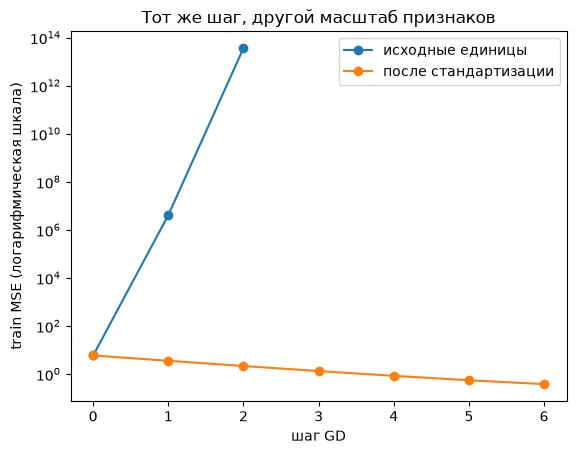

In [9]:
A_units = np.column_stack([X_train_units, np.ones(len(X_train))])
A_scaled = np.column_stack([X_train_scaled, np.ones(len(X_train))])
def short_gd(A, target, rate, steps=6):
    theta = np.zeros(A.shape[1])
    losses = [mean_squared_error(target, A @ theta)]
    for _ in range(steps):
        theta -= rate * mse_gradient(A, target, theta)
        losses.append(mean_squared_error(target, A @ theta))
        if losses[-1] > 1e12:
            break
    return losses

for name, A in [("исходные единицы", A_units), ("после стандартизации", A_scaled)]:
    limit = 1 / np.linalg.eigvalsh(A.T @ A / len(A))[-1]
    losses = short_gd(A, y_train, learning_rate)
    print(f"{name}: устойчивый шаг < {limit:.6f}; MSE {losses[0]:.2g} → {losses[-1]:.2g} за {len(losses)-1} шагов")
    plt.plot(range(len(losses)), losses, marker="o", label=name)
plt.yscale("log")
plt.xlabel("шаг GD")
plt.ylabel("train MSE (логарифмическая шкала)")
plt.title("Тот же шаг, другой масштаб признаков")
plt.legend()
plt.show()

<details><summary><b>Разбор</b></summary>

Масштабирование улучшает численную геометрию для итерационного метода. При **обратимом** аффинном преобразовании признаков меняются коэффициенты и свободный член МНК, но сохраняются прогнозы; это проверено для выбранной смены единиц. Для Ridge масштаб уже влияет и на относительную силу штрафа. Test не должен задавать средние и дисперсии преобразования: иначе сведения о нём попадут в обучение.

</details>

## Итоги и exit ticket

1. Почему `np.linalg.lstsq` предпочтительнее явного `inv(X.T @ X)` для МНК?
2. Что можно и нельзя заключить о весах, если прогнозы моделей близки, а признаки почти совпадают?
3. Где в формулах выше стоит множитель $1/m$? Как из-за него связаны $\lambda$ и `Ridge(alpha=...)`?
4. Почему нельзя сравнивать коэффициенты до и после `StandardScaler` по абсолютной разнице?
5. Когда именно разрешено смотреть на test?

**Самостоятельный опыт:** поменяйте только `learning_rate` в блоке GD и постройте тот же график. Найдите шаг, при котором MSE перестанет устойчиво уменьшаться; верните исходное значение перед продолжением семинара.

## Происхождение и ограничения

Материал переработан из исходного `seminar_02_linear_regression_raw.ipynb` для второго семинара курса. Ритм «прогноз → запуск → разбор», воспроизводимый seed и проверка утечки следуют первому семинару `knn_validation_stability.ipynb`. Выводы об устойчивости и сходимости относятся к конкретным синтетическим опытам, а не ко всем наборам данных. Формулы МНК и Ridge сопоставлены с документацией [NumPy `lstsq`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html) и [scikit-learn `Ridge`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html).